<a href="https://colab.research.google.com/github/iaprojectsit/M08-Fundamentos_da_otica_quantica/blob/main/Simula%C3%A7%C3%A3o_das_Correla%C3%A7%C3%B5es_no_OPO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- RESULTADOS DA SIMULAÇÃO OPO ---
Variância do Sinal: 10.10
Variância do Idler: 10.13
Variância da Diferença: 0.1004 (Limite de Shot Noise = 1.0)
Conclusão: Emaranhamento Confirmado! Ruído de subtração abaixo do Shot Noise.


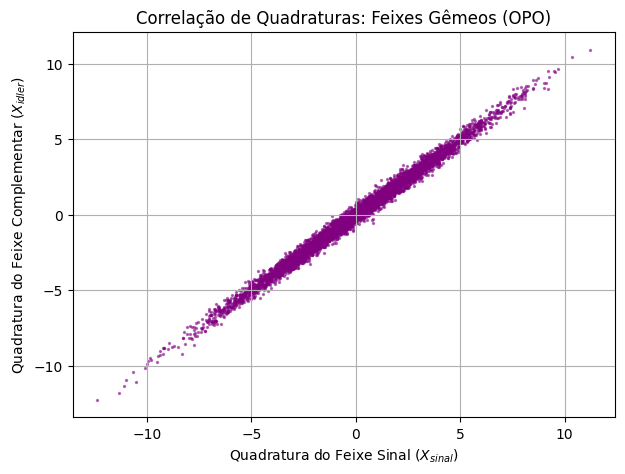

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def simular_opo_emaranhamento(ganho_parametrico=1.5, num_amostras=5000):
    """
    Simula o emaranhamento de variáveis contínuas (squeezing) gerado
    entre os modos Sinal e Complementar (Idler) em um OPO.
    """
    np.random.seed(42)
    # Vácuo quântico incidente (ruído normalizado)
    vacuo_1 = np.random.normal(0, 1, num_amostras)
    vacuo_2 = np.random.normal(0, 1, num_amostras)

    # Transformação de Bogoliubov (Amplificação Paramétrica)
    # X_sinal e X_idler representam as quadraturas de amplitude geradas
    g = ganho_parametrico
    X_sinal = np.cosh(g) * vacuo_1 + np.sinh(g) * vacuo_2
    X_idler = np.sinh(g) * vacuo_1 + np.cosh(g) * vacuo_2

    # A assinatura do emaranhamento é dada pela redução do ruído na diferença
    diferenca = X_sinal - X_idler

    # Cálculos das Variâncias
    var_sinal = np.var(X_sinal)
    var_idler = np.var(X_idler)
    var_diferenca = np.var(diferenca)

    print(f"--- RESULTADOS DA SIMULAÇÃO OPO ---")
    print(f"Variância do Sinal: {var_sinal:.2f}")
    print(f"Variância do Idler: {var_idler:.2f}")
    print(f"Variância da Diferença: {var_diferenca:.4f} (Limite de Shot Noise = 1.0)")

    if var_diferenca < 1.0:
         print("Conclusão: Emaranhamento Confirmado! Ruído de subtração abaixo do Shot Noise.")

    # Gráfico de dispersão evidenciando a correlação
    plt.figure(figsize=(7,5))
    plt.scatter(X_sinal, X_idler, alpha=0.5, color='purple', s=2)
    plt.title('Correlação de Quadraturas: Feixes Gêmeos (OPO)', fontsize=12)
    plt.xlabel('Quadratura do Feixe Sinal ($X_{sinal}$)')
    plt.ylabel('Quadratura do Feixe Complementar ($X_{idler}$)')
    plt.grid(True)
    plt.show()

simular_opo_emaranhamento()